# Experimento 3: CLIP + DINOv2 (fusión visual, sin metadata)
**Estrategia:** Concatenar embeddings CLIP (768) + DINOv2 (1024) → cabeza lineal  
**Dataset:** PAD-UFES-20 — clasificación binaria (maligno vs benigno)  
**Nota:** Los embeddings ya están guardados — este notebook solo los fusiona y entrena

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: Tesla T4


## 1. Cargar embeddings guardados

In [3]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')

# Cargar embeddings CLIP (768-dim)
clip_train = np.load(os.path.join(RESULTS_PATH, 'clip_X_train.npy'))
clip_val   = np.load(os.path.join(RESULTS_PATH, 'clip_X_val.npy'))
clip_test  = np.load(os.path.join(RESULTS_PATH, 'clip_X_test.npy'))

# Cargar embeddings DINOv2 (1024-dim)
dino_train = np.load(os.path.join(RESULTS_PATH, 'dino_X_train.npy'))
dino_val   = np.load(os.path.join(RESULTS_PATH, 'dino_X_val.npy'))
dino_test  = np.load(os.path.join(RESULTS_PATH, 'dino_X_test.npy'))

# Cargar labels
y_train = np.load(os.path.join(RESULTS_PATH, 'y_train.npy'))
y_val   = np.load(os.path.join(RESULTS_PATH, 'y_val.npy'))
y_test  = np.load(os.path.join(RESULTS_PATH, 'y_test.npy'))

print(f'CLIP  — train: {clip_train.shape} | val: {clip_val.shape} | test: {clip_test.shape}')
print(f'DINOv2 — train: {dino_train.shape} | val: {dino_val.shape} | test: {dino_test.shape}')

CLIP  — train: (1838, 768) | val: (230, 768) | test: (230, 768)
DINOv2 — train: (1838, 1024) | val: (230, 1024) | test: (230, 1024)


## 2. Fusión por concatenación (CLIP ∥ DINOv2)

In [4]:
# Concatenar: 768 + 1024 = 1792 dimensiones
X_train = np.concatenate([clip_train, dino_train], axis=1)
X_val   = np.concatenate([clip_val,   dino_val],   axis=1)
X_test  = np.concatenate([clip_test,  dino_test],  axis=1)

print(f'Fusionado — train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}')
print(f'Dimensión: 768 (CLIP) + 1024 (DINOv2) = {X_train.shape[1]}')

Fusionado — train: (1838, 1792) | val: (230, 1792) | test: (230, 1792)
Dimensión: 768 (CLIP) + 1024 (DINOv2) = 1792


## 3. DataLoaders

In [5]:
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32)
X_v  = torch.tensor(X_val,   dtype=torch.float32)
y_v  = torch.tensor(y_val,   dtype=torch.float32)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_v,  y_v),  batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=64, shuffle=False)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 29 | Val: 4 | Test: 4


## 4. Cabeza lineal entrenable

In [6]:
# 1792 → 512 → 256 → 1  (más capacidad por el vector más grande)
head = nn.Sequential(
    nn.Linear(1792, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1)
).to(device)

trainable = sum(p.numel() for p in head.parameters())
print(f'Parámetros entrenables: {trainable:,}')

Parámetros entrenables: 1,049,601


## 5. Entrenamiento

In [7]:
EPOCHS    = 30
LR        = 1e-3
THRESHOLD = 0.5
PATIENCE  = 10

criterion       = nn.BCEWithLogitsLoss()
optimizer       = torch.optim.Adam(head.parameters(), lr=LR, weight_decay=1e-4)
scheduler       = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_auc    = 0
patience_count  = 0
best_model_path = os.path.join(RESULTS_PATH, 'clip_dino_head.pt')
history         = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(EPOCHS):
    head.train()
    train_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(head(X_b).squeeze(1), y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    head.eval()
    val_loss, val_probs, val_labels = 0, [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out       = head(X_b).squeeze(1)
            val_loss += criterion(out, y_b).item()
            val_probs.extend(torch.sigmoid(out).cpu().numpy())
            val_labels.extend(y_b.cpu().numpy())
    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(val_labels, val_probs)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f'Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(head.state_dict(), best_model_path)
        patience_count = 0
        print(f' Mejor modelo guardado (AUC={best_val_auc:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'  Early stopping en epoch {epoch+1}')
            break

print(f'\nMejor Val AUC: {best_val_auc:.4f}')

Epoch 01 | Train Loss: 0.6096 | Val Loss: 0.4793 | Val AUC: 0.8678
 Mejor modelo guardado (AUC=0.8678)
Epoch 02 | Train Loss: 0.4229 | Val Loss: 0.3928 | Val AUC: 0.9103
 Mejor modelo guardado (AUC=0.9103)
Epoch 03 | Train Loss: 0.3768 | Val Loss: 0.3748 | Val AUC: 0.9136
 Mejor modelo guardado (AUC=0.9136)
Epoch 04 | Train Loss: 0.3545 | Val Loss: 0.3662 | Val AUC: 0.9189
 Mejor modelo guardado (AUC=0.9189)
Epoch 05 | Train Loss: 0.3295 | Val Loss: 0.3609 | Val AUC: 0.9207
 Mejor modelo guardado (AUC=0.9207)
Epoch 06 | Train Loss: 0.3275 | Val Loss: 0.3646 | Val AUC: 0.9266
 Mejor modelo guardado (AUC=0.9266)
Epoch 07 | Train Loss: 0.2989 | Val Loss: 0.3645 | Val AUC: 0.9211
Epoch 08 | Train Loss: 0.2853 | Val Loss: 0.3763 | Val AUC: 0.9192
Epoch 09 | Train Loss: 0.2834 | Val Loss: 0.3876 | Val AUC: 0.9199
Epoch 10 | Train Loss: 0.2673 | Val Loss: 0.3878 | Val AUC: 0.9165
Epoch 11 | Train Loss: 0.2460 | Val Loss: 0.3686 | Val AUC: 0.9260
Epoch 12 | Train Loss: 0.2290 | Val Loss: 0.377

## 6. Curvas de entrenamiento

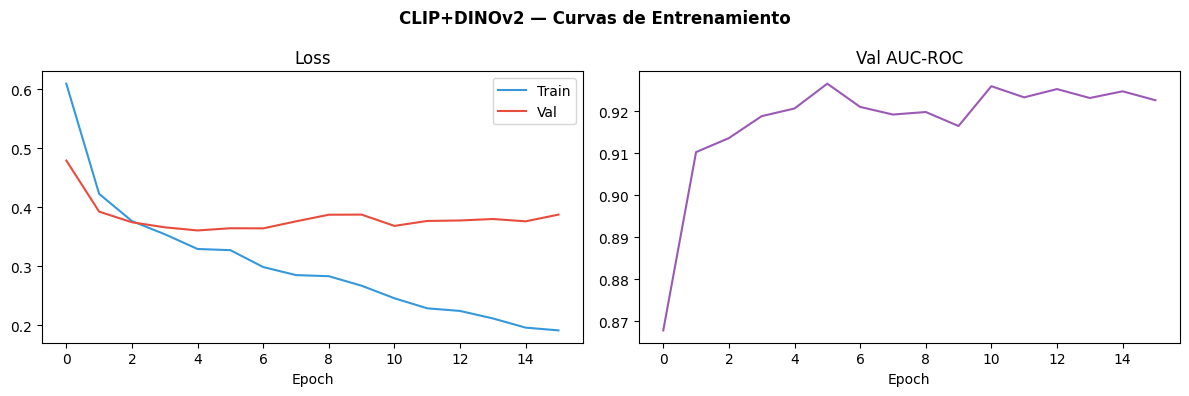

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train', color='#3498db')
axes[0].plot(history['val_loss'],   label='Val',   color='#e74c3c')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history['val_auc'], color='#9b59b6')
axes[1].set_title('Val AUC-ROC')
axes[1].set_xlabel('Epoch')
plt.suptitle('CLIP+DINOv2 — Curvas de Entrenamiento', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'clip_dino_curvas.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluación en Test

In [9]:
head.load_state_dict(torch.load(best_model_path))
head.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = head(X_b.to(device)).squeeze(1)
        test_probs.extend(torch.sigmoid(out).cpu().numpy())
        test_labels.extend(y_b.numpy())

test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)
test_preds  = (test_probs >= THRESHOLD).astype(int)

auc       = roc_auc_score(test_labels, test_probs)
accuracy  = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall    = recall_score(test_labels, test_preds)
f1        = f1_score(test_labels, test_preds)

print('=' * 50)
print('  RESULTADOS — CLIP + DINOv2 (sin metadata)')
print('=' * 50)
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Accuracy  : {accuracy*100:.1f}%')
print(f'  Precision : {precision*100:.1f}%')
print(f'  Recall    : {recall*100:.1f}%')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 50)
print()
print(classification_report(test_labels, test_preds, target_names=['Benigno', 'Maligno']))

  RESULTADOS — CLIP + DINOv2 (sin metadata)
  AUC-ROC   : 0.9098
  Accuracy  : 81.3%
  Precision : 75.6%
  Recall    : 90.0%
  F1-Score  : 0.8216

              precision    recall  f1-score   support

     Benigno       0.89      0.73      0.80       120
     Maligno       0.76      0.90      0.82       110

    accuracy                           0.81       230
   macro avg       0.82      0.82      0.81       230
weighted avg       0.83      0.81      0.81       230



## 8. Matriz de confusión

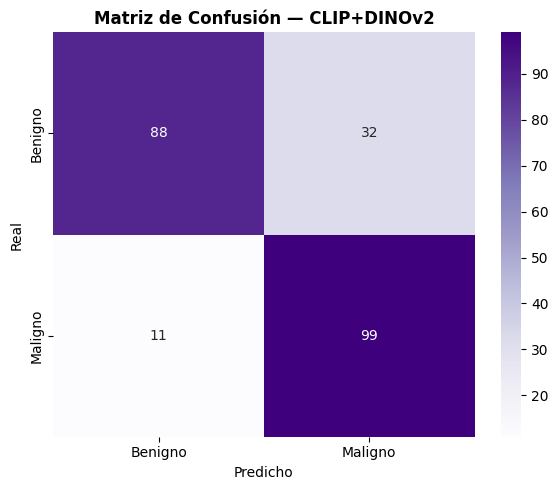

In [10]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'], ax=ax)
ax.set_title('Matriz de Confusión — CLIP+DINOv2', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'clip_dino_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar resultados

In [11]:
results = {
    'modelo':    'CLIP+DINOv2 (sin metadata)',
    'backbone':  'ViT-L/14 CLIP + ViT-L/14 DINOv2',
    'auc':       round(auc, 4),
    'accuracy':  round(accuracy, 4),
    'precision': round(precision, 4),
    'recall':    round(recall, 4),
    'f1':        round(f1, 4),
}
results_path = os.path.join(RESULTS_PATH, 'resultados_clip_dino.csv')
pd.DataFrame([results]).to_csv(results_path, index=False)
print(f' Resultados guardados en: {results_path}')
print(pd.DataFrame([results]))

 Resultados guardados en: /content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20/resultados/resultados_clip_dino.csv
                       modelo                         backbone     auc  \
0  CLIP+DINOv2 (sin metadata)  ViT-L/14 CLIP + ViT-L/14 DINOv2  0.9098   

   accuracy  precision  recall      f1  
0     0.813     0.7557     0.9  0.8216  
